# 🏥 Tech Challenge — FIAP Pós 9IADT 2026 — Fase 1
## Sistema inteligente de apoio à triagem de mulheres vítimas de violência
---
> **Dados de treino**: Notificações históricas SINAN - 2010 à 2025 (`violencia_BR_25.csv`)  
> **Saída**: Probabilidade de tipo de violência e encaminhamento/exame ser necessário  
---

### 🎯 Modelos comparados neste notebook

| # | Modelo | Tipo | Justificativa |
|---|--------|------|---------------|
| 1 | **Random Forest** | Ensemble (Bagging) | robusto e estável |
| 2 | **XGBoost** | Ensemble (Boosting) | Alta performance em dados tabulares desbalanceados |
| 3 | **Logistic Regression** | Linear | Interpretável, rápido, boa base de comparação |

---

### ⚠️ Aviso Ético
> O sistema é um **apoio à decisão clínica**.
> A avaliação final é sempre responsabilidade do profissional de saúde.  
> Todos os dados tratados conforme **LGPD (Lei nº 13.709/2018)**.

---
## 1️⃣ Importar o dataset
---

In [7]:
import numpy as np
import os
import zipfile
import glob
import pandas as pd
import jinja2

def extract_all_zips(data_dir='data'):
    """Extrai todos os arquivos .zip encontrados em data_dir para a mesma pasta."""
    os.makedirs(data_dir, exist_ok=True)
    zip_paths = glob.glob(os.path.join(data_dir, '*.zip'))
    if not zip_paths:
        print("🔎 Nenhum arquivo .zip encontrado em", data_dir)
        return []
    extracted_files = []
    for zp in zip_paths:
        try:
            with zipfile.ZipFile(zp, 'r') as z:
                z.extractall(data_dir)
                extracted_files.extend(z.namelist())
            print(f"✅ Extraído: {os.path.basename(zp)}")
        except zipfile.BadZipFile:
            print(f"⚠️ Arquivo zip corrompido ou inválido: {zp}")
    return zip_paths


def _read_csv_try(path, max_cols_warn=1000):
    """Tenta ler CSV com combinações comuns de encoding e separador.
       Se o número de colunas for suspeito, emite aviso.
    """
    encodings = ['latin-1', 'utf-8', 'cp1252']
    seps = [',']
    for enc in encodings:
        for sep in seps:
            try:
                df = pd.read_csv(path, sep=sep, encoding=enc, low_memory=False)
                # Checagem de sanidade
                if df.shape[1] > max_cols_warn:
                    print(f"⚠️ {path} lido com {df.shape[1]} colunas (possível separador errado: '{sep}', encoding '{enc}')")
                return df
            except Exception:
                continue
    # última tentativa: deixar o pandas inferir (pode falhar)
    df = pd.read_csv(path, low_memory=False)
    if df.shape[1] > max_cols_warn:
        print(f"⚠️ {path} lido com {df.shape[1]} colunas (pandas inferiu separador/encoding)")
    return df


def load_all_csvs(data_dir='data', concat=False,delete_after_load=False):
    """
    Extrai zips em data_dir, carrega todos os CSVs e retorna:
      - dict_of_dfs: dict {filename: DataFrame}
      - concatenated_df (ou None): DataFrame concatenado se concat=True
    """
    # 1) extrai todos os zips encontrados
    extract_all_zips(data_dir)

    # 2) encontra todos os CSVs (após extração)
    csv_paths = glob.glob(os.path.join(data_dir, '**', '*.csv'), recursive=True)
    if not csv_paths:
        raise FileNotFoundError(f"Nenhum arquivo .csv encontrado em '{data_dir}'.")

    dict_of_dfs = {}
    for p in csv_paths:
        fname = os.path.relpath(p, data_dir)
        try:
            df = _read_csv_try(p)
            dict_of_dfs[fname] = df
            print(f"📥 Carregado: {fname} (linhas: {len(df)}, colunas: {len(df.columns)})")
        except Exception as e:
            print(f"❌ Falha ao carregar {fname}: {e}")

    concatenated_df = None
    if concat and dict_of_dfs:
        try:
            concatenated_df = pd.concat(dict_of_dfs.values(), ignore_index=True, sort=False)
            print(f"🔗 DataFrames concatenados: {len(dict_of_dfs)} arquivos -> {len(concatenated_df)} linhas")
        except Exception as e:
            print(f"⚠️ Não foi possível concatenar os DataFrames automaticamente: {e}")

     # 3) excluir CSVs se solicitado
    deleted_count = 0
    if delete_after_load:
        # Re-obter lista para garantir que pegamos todos os CSVs atuais
        csv_paths_to_delete = glob.glob(os.path.join(data_dir, '**', '*.csv'), recursive=True)
        for p in csv_paths_to_delete:
            try:
                os.remove(p)
                deleted_count += 1
            except Exception as e:
                print(f"⚠️ Não foi possível excluir {p}: {e}")
        print(f"🗑️  Arquivos .csv excluídos: {deleted_count}")            

    return dict_of_dfs, concatenated_df

# Exemplo de uso:
# dict_dfs, df_all = load_all_csvs('data', concat=True)
# acessar um DataFrame específico: dict_dfs['violencia_BR_25.csv']

In [8]:
# --- Rotina principal usando as funções acima ---
import time

start = time.time()

# Carrega todos os CSVs extraídos em data/ e concatena em um único DataFrame
dict_dfs, dados_concatenados = load_all_csvs('data', concat=True, delete_after_load=True)

elapsed = time.time() - start
print(f"⏱️  Tempo de carregamento: {elapsed:.2f}s")

# Se quiser trabalhar com o DataFrame concatenado (todos os CSVs juntos)
if dados_concatenados is not None:
    print(f"📊 Shape total concatenado: {dados_concatenados.shape}")
else:
    # Caso não tenha pedido concatenação, mostra resumo por arquivo
    total_rows = sum(df.shape[0] for df in dict_dfs.values())
    total_cols = max((df.shape[1] for df in dict_dfs.values()), default=0)
    print(f"📊 Shape total estimado: linhas={total_rows}, colunas_max={total_cols}")


✅ Extraído: violencia_BR_11.zip
📥 Carregado: violencia_BR_11.csv (linhas: 107530, colunas: 160)
🔗 DataFrames concatenados: 1 arquivos -> 107530 linhas
🗑️  Arquivos .csv excluídos: 1
⏱️  Tempo de carregamento: 2.36s
📊 Shape total concatenado: (107530, 160)


In [9]:
# Visão geral do dataset
print("=== Tipos de dados ===")
print(dados_concatenados.dtypes.value_counts())
print()
print("=== Primeiros registros ===")
dados_concatenados.head(3)


=== Tipos de dados ===
float64    128
object      24
int64        8
Name: count, dtype: int64

=== Primeiros registros ===


,TP_NOT,ID_AGRAVO,DT_NOTIFIC,SEM_NOT,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_UNIDADE,DT_OCOR,SEM_PRI,...,CONS_IDO,DELEG_IDOS,DIR_HUMAN,MPU,DELEG_CRIA,DELEG_MULH,DELEG,INFAN_JUV,DEFEN_PUBL,DT_ENCERRA
0,2,Y09,2011-07-03,201127,2011,31,314270,2119439.0,2011-07-03,201127,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011-08-01
1,2,Y09,2011-08-14,201133,2011,31,315250,2127989.0,2011-08-14,201133,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011-08-14
2,2,Y09,2011-01-01,201052,2011,23,231050,2723255.0,2011-01-01,201052,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011-01-03


---

***Contagem de registros por sexo da vítima notificada dos datasets carregados***

---

In [10]:
# Verificação da quantidade de registros
contagem = dados_concatenados.groupby("CS_SEXO").size()

print(f"📋 Shape (todos arquivos): {dados_concatenados.shape}\n")
print(f"lista de grupos:\n{contagem}\n")
print("F-Feminino / M-Masculino / I-Ignorado") 


📋 Shape (todos arquivos): (107530, 160)

lista de grupos:
CS_SEXO
F    75033
I       66
M    32431
dtype: int64

F-Feminino / M-Masculino / I-Ignorado


---

**Filtrar e copiar apenas os dados de notificações de vítimas do sexo feminino**

---

In [11]:


# Filtrar apenas vítimas do sexo feminino (conforme objetivo do sistema)
dadosFemininos = dados_concatenados[dados_concatenados['CS_SEXO'] == 'F'].copy()

print(f"✅ Registros femininos: {dadosFemininos.shape[0]:,} linhas × {dadosFemininos.shape[1]} colunas")
print(f"\n📋 Amostra dos dados:")

dadosFemininos.head(5)

✅ Registros femininos: 75,033 linhas × 160 colunas

📋 Amostra dos dados:


,TP_NOT,ID_AGRAVO,DT_NOTIFIC,SEM_NOT,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_UNIDADE,DT_OCOR,SEM_PRI,...,CONS_IDO,DELEG_IDOS,DIR_HUMAN,MPU,DELEG_CRIA,DELEG_MULH,DELEG,INFAN_JUV,DEFEN_PUBL,DT_ENCERRA
0,2,Y09,2011-07-03,201127,2011,31,314270,2119439.0,2011-07-03,201127,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011-08-01
1,2,Y09,2011-08-14,201133,2011,31,315250,2127989.0,2011-08-14,201133,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011-08-14
2,2,Y09,2011-01-01,201052,2011,23,231050,2723255.0,2011-01-01,201052,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011-01-03
3,2,Y09,2011-01-03,201101,2011,25,250510,2342642.0,2011-01-03,201101,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011-01-03
4,2,Y09,2011-01-13,201102,2011,23,230445,2372568.0,2011-01-13,201102,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011-01-13


---

**Informações gerais - total de linhas, colunas e tipos de dados**

---

In [12]:
# Informações gerais do subconjunto feminino
print(f"📋 Shape (feminino): {dadosFemininos.shape}")
print()
print("=== Colunas e tipos ===")
dadosFemininos.dtypes


📋 Shape (feminino): (75033, 160)

=== Colunas e tipos ===


TP_NOT          int64
ID_AGRAVO      object
DT_NOTIFIC     object
SEM_NOT         int64
NU_ANO          int64
               ...   
DELEG_MULH    float64
DELEG         float64
INFAN_JUV     float64
DEFEN_PUBL    float64
DT_ENCERRA     object
Length: 160, dtype: object

---
## 2️⃣ Análise Exploratória de Dados (EDA)
---
> Carregamos a base, exploramos características gerais, estatísticas descritivas,
> distribuições e padrões específicos relacionados à saúde e segurança feminina.


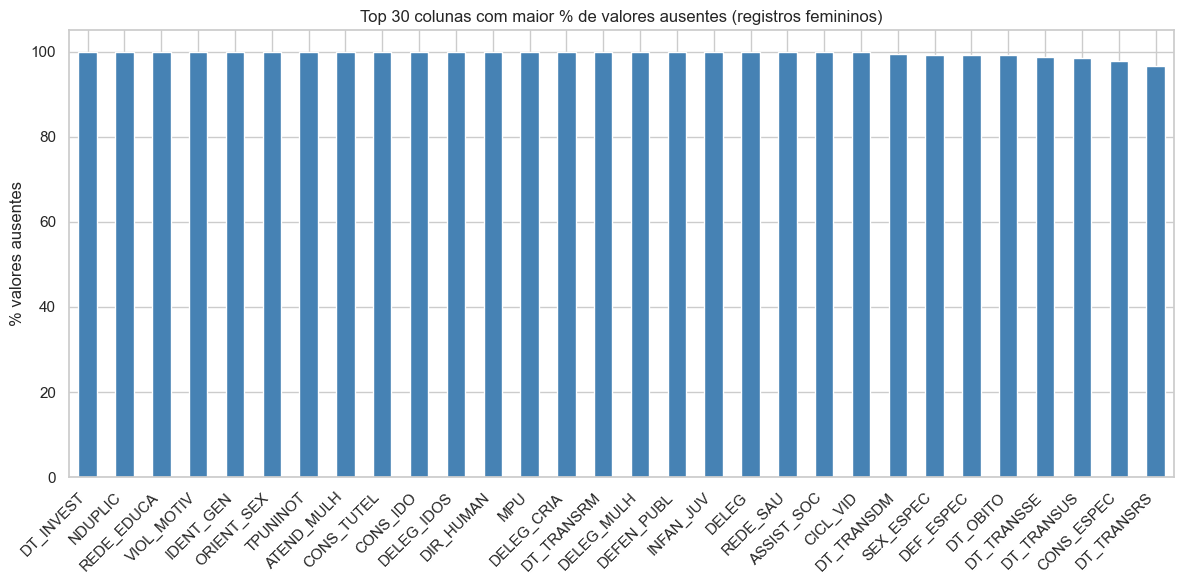

Colunas sem nenhum valor ausente: 13
Colunas com > 80 % ausentes: 37


In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

# Análise de valores ausentes / ignorados no subconjunto feminino
missing = (dadosFemininos.isnull().sum() / len(dadosFemininos) * 100)
missing = missing[missing > 0].sort_values(ascending=False).head(30)

plt.figure(figsize=(12, 6))
missing.plot(kind='bar', color='steelblue')
plt.title("Top 30 colunas com maior % de valores ausentes (registros femininos)")
plt.ylabel("% valores ausentes")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"Colunas sem nenhum valor ausente: {(dadosFemininos.isnull().sum() == 0).sum()}")
print(f"Colunas com > 80 % ausentes: {(dadosFemininos.isnull().mean() > 0.8).sum()}")


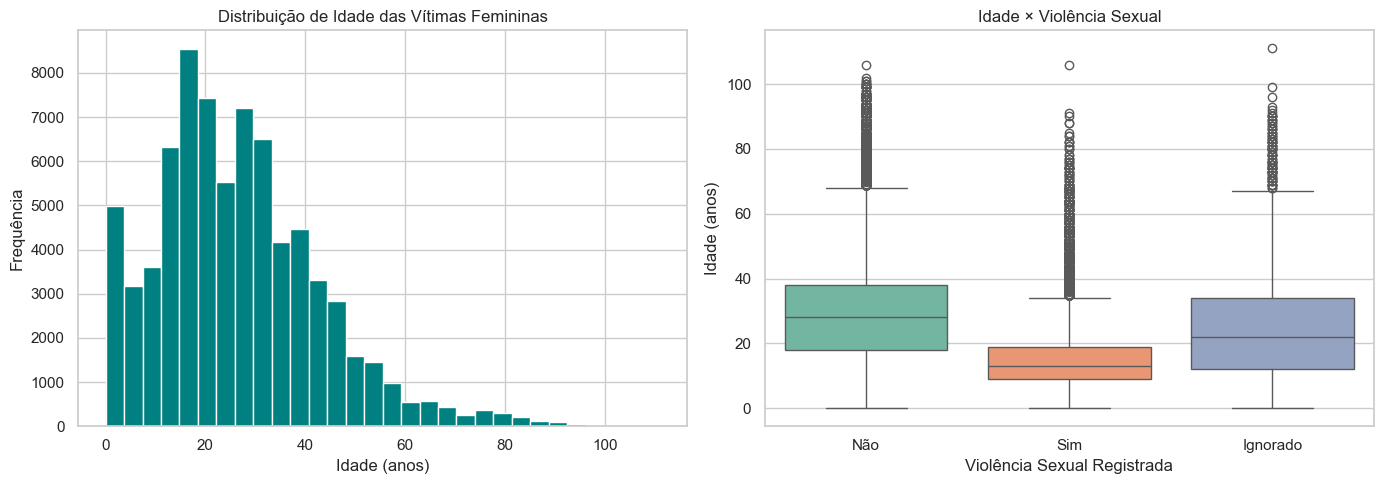

count    75033.0
mean        26.4
std         16.4
min          0.0
25%         15.0
50%         24.0
75%         36.0
max        111.0
Name: IDADE_ANOS, dtype: float64


In [14]:
# Extração da idade em anos a partir do campo codificado NU_IDADE_N
# Formato: primeiro dígito = unidade (4 = anos), demais dígitos = valor
def decode_age_years(val):
    if pd.isna(val):
        return np.nan
    v = int(val)
    unit = v // 1000   # 1=hora, 2=dia, 3=mês, 4=ano
    num  = v  % 1000
    if unit == 4:
        return num
    elif unit == 3:
        return num / 12
    elif unit == 2:
        return num / 365
    else:
        return 0

dadosFemininos = dadosFemininos.copy()
dadosFemininos['IDADE_ANOS'] = dadosFemininos['NU_IDADE_N'].apply(decode_age_years)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(dadosFemininos['IDADE_ANOS'].dropna(), bins=30, color='teal', edgecolor='white')
axes[0].set_title("Distribuição de Idade das Vítimas Femininas")
axes[0].set_xlabel("Idade (anos)")
axes[0].set_ylabel("Frequência")

# Boxplot por tipo de violência sexual
viol_sexu_label = dadosFemininos['VIOL_SEXU'].map({1.0: 'Sim', 2.0: 'Não', 9.0: 'Ignorado'})
sns.boxplot(
    x=viol_sexu_label,
    y=dadosFemininos['IDADE_ANOS'],
    hue=viol_sexu_label,   # usa a própria variável como hue
    ax=axes[1],
    palette="Set2",
    legend=False           # remove legenda se não precisar
)

axes[1].set_title("Idade × Violência Sexual")
axes[1].set_xlabel("Violência Sexual Registrada")
axes[1].set_ylabel("Idade (anos)")

plt.tight_layout()
plt.show()

print(dadosFemininos['IDADE_ANOS'].describe().round(1))


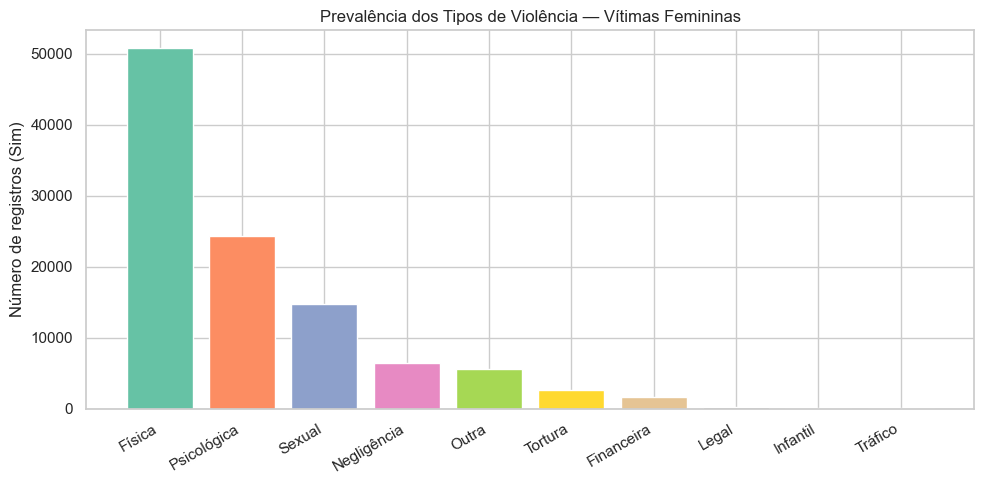

Percentual de Sim (valor=1) por tipo de violência:
  Física              :  67.6 %
  Psicológica         :  32.4 %
  Tortura             :   3.5 %
  Sexual              :  19.7 %
  Tráfico             :   0.1 %
  Financeira          :   2.1 %
  Negligência         :   8.7 %
  Infantil            :   0.2 %
  Legal               :   0.3 %
  Outra               :   7.4 %


In [15]:
# Distribuição dos tipos de violência registrados
# Valor 1 = Sim, 2 = Não/Outro, 9 = Ignorado
viol_cols = {
    'VIOL_FISIC': 'Física',
    'VIOL_PSICO': 'Psicológica',
    'VIOL_TORT':  'Tortura',
    'VIOL_SEXU':  'Sexual',
    'VIOL_TRAF':  'Tráfico',
    'VIOL_FINAN': 'Financeira',
    'VIOL_NEGLI': 'Negligência',
    'VIOL_INFAN': 'Infantil',
    'VIOL_LEGAL': 'Legal',
    'VIOL_OUTR':  'Outra',
}

prevalencia = {
    label: (dadosFemininos[col] == 1).sum()
    for col, label in viol_cols.items()
    if col in dadosFemininos.columns
}
prevalencia = dict(sorted(prevalencia.items(), key=lambda x: x[1], reverse=True))

plt.figure(figsize=(10, 5))
plt.bar(prevalencia.keys(), prevalencia.values(), color=sns.color_palette("Set2", len(prevalencia)))
plt.title("Prevalência dos Tipos de Violência — Vítimas Femininas")
plt.ylabel("Número de registros (Sim)")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print("Percentual de Sim (valor=1) por tipo de violência:")
for col, label in viol_cols.items():
    if col in dadosFemininos.columns:
        pct = (dadosFemininos[col] == 1).mean() * 100
        print(f"  {label:20s}: {pct:5.1f} %")


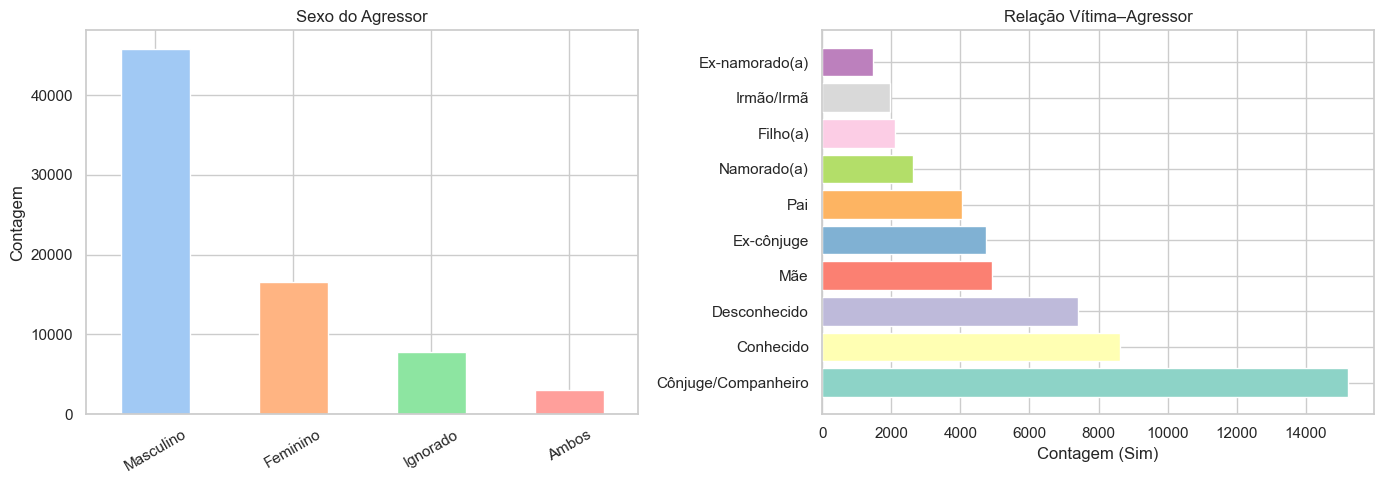

Uso de álcool pelo agressor:
AUTOR_ALCO
Não         36.1
Ignorado    35.7
Sim         28.2


In [16]:
# Análise do perfil do agressor
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sexo do agressor
sexo_agr = dadosFemininos['AUTOR_SEXO'].map({1.0: 'Masculino', 2.0: 'Feminino',
                                              3.0: 'Ambos', 9.0: 'Ignorado'})
sexo_agr.value_counts().plot(kind='bar', ax=axes[0], color=sns.color_palette("pastel"))
axes[0].set_title("Sexo do Agressor")
axes[0].set_xlabel("")
axes[0].set_ylabel("Contagem")
axes[0].tick_params(axis='x', rotation=30)

# Relação vítima–agressor (top 8)
rel_cols = {
    'REL_CONJ': 'Cônjuge/Companheiro', 'REL_EXCON': 'Ex-cônjuge',
    'REL_NAMO': 'Namorado(a)',          'REL_EXNAM': 'Ex-namorado(a)',
    'REL_PAI':  'Pai',                  'REL_MAE':  'Mãe',
    'REL_FILHO':'Filho(a)',             'REL_DESCO':'Desconhecido',
    'REL_IRMAO':'Irmão/Irmã',          'REL_CONHEC':'Conhecido',
}
rel_counts = {
    label: (dadosFemininos[col] == 1).sum()
    for col, label in rel_cols.items()
    if col in dadosFemininos.columns
}
rel_counts = dict(sorted(rel_counts.items(), key=lambda x: x[1], reverse=True))
axes[1].barh(list(rel_counts.keys()), list(rel_counts.values()),
             color=sns.color_palette("Set3", len(rel_counts)))
axes[1].set_title("Relação Vítima–Agressor")
axes[1].set_xlabel("Contagem (Sim)")

plt.tight_layout()
plt.show()

# Uso de álcool pelo agressor
alco = dadosFemininos['AUTOR_ALCO'].map({1.0: 'Sim', 2.0: 'Não', 9.0: 'Ignorado'})
print("Uso de álcool pelo agressor:")
print(alco.value_counts(normalize=True).mul(100).round(1).to_string())


In [17]:
# Estatísticas descritivas e ocorrência repetida
print("=== Estatísticas descritivas (numéricas) ===")
display(dadosFemininos[['IDADE_ANOS']].describe().round(2))

print()
print("=== Violência repetida (OUT_VEZES) ===")
repeticao = dadosFemininos['OUT_VEZES'].map({1.0: 'Sim — ocorreu outras vezes',
                                              2.0: 'Não — primeira vez',
                                              9.0: 'Ignorado'})
print(repeticao.value_counts(normalize=True).mul(100).round(1).to_string())

print()
print("=== Local de ocorrência (TOP 5) ===")
local_map = {1.0:'Residência', 2.0:'Habitação coletiva', 3.0:'Escola',
             4.0:'Local de prática esportiva', 5.0:'Bar/Boate',
             6.0:'Via pública', 7.0:'Comércio/Serviços', 8.0:'Indústrias',
             9.0:'Outros', 99.0:'Ignorado'}
local_lbl = dadosFemininos['LOCAL_OCOR'].map(local_map)
print(local_lbl.value_counts(normalize=True).mul(100).round(1).head(5).to_string())


=== Estatísticas descritivas (numéricas) ===


,IDADE_ANOS
count,75033.00
mean,26.44
std,16.40
min,0.00
25%,15.00
50%,24.00
75%,36.00
max,111.00



=== Violência repetida (OUT_VEZES) ===
OUT_VEZES
Sim — ocorreu outras vezes    38.2
Não — primeira vez            36.4
Ignorado                      25.4

=== Local de ocorrência (TOP 5) ===
LOCAL_OCOR
Residência     63.8
Via pública    13.7
Ignorado       11.2
Outros          5.6
Bar/Boate       1.9


---
## 3️⃣ Pré-processamento de dados
---
> Limpeza, seleção de features, tratamento de valores ausentes/ignorados,
> encoding e análise de correlação.


In [18]:
# ── 3.1 Seleção das features relevantes para o modelo ─────────────────────────
# Target: VIOL_SEXU (1 = violência sexual registrada, 0 = demais)

FEATURES_NUMERICAS = ['IDADE_ANOS']

FEATURES_BINARIAS = [
    # Tipos de violência co-ocorrentes
    'VIOL_FISIC', 'VIOL_PSICO', 'VIOL_TORT', 'VIOL_FINAN',
    'VIOL_NEGLI', 'VIOL_INFAN', 'VIOL_LEGAL', 'VIOL_OUTR',
    # Automutilação / lesão autoprovocada
    'LES_AUTOP',
    # Perfil agressor
    'AUTOR_ALCO',
    # Repetição
    'OUT_VEZES',
]

FEATURES_CATEGORICAS = [
    'CS_GESTANT',   # gestação
    'CS_RACA',      # raça/cor
    'CS_ESCOL_N',   # escolaridade
    'LOCAL_OCOR',   # local de ocorrência
    'AUTOR_SEXO',   # sexo do agressor
]

TARGET = 'VIOL_SEXU'

all_features = FEATURES_NUMERICAS + FEATURES_BINARIAS + FEATURES_CATEGORICAS

# Colunas disponíveis no dataset
all_features = [c for c in all_features if c in dadosFemininos.columns]

df_model = dadosFemininos[all_features + [TARGET]].copy()
print(f"Shape inicial para modelagem: {df_model.shape}")
df_model.head(3)


Shape inicial para modelagem: (75033, 18)


,IDADE_ANOS,VIOL_FISIC,VIOL_PSICO,VIOL_TORT,VIOL_FINAN,VIOL_NEGLI,VIOL_INFAN,VIOL_LEGAL,VIOL_OUTR,LES_AUTOP,AUTOR_ALCO,OUT_VEZES,CS_GESTANT,CS_RACA,CS_ESCOL_N,LOCAL_OCOR,AUTOR_SEXO,VIOL_SEXU
0,37.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,1.0,5,4.0,9.0,1.0,1.0,2.0
1,43.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,1.0,5,1.0,9.0,1.0,1.0,2.0
2,23.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,1.0,5,4.0,4.0,6.0,1.0,2.0


In [19]:
# ── 3.2 Tratamento da variável alvo ───────────────────────────────────────────
# 1 = violência sexual; 2 = não; 9 = ignorado → removemos ignorados, binarizamos
df_model = df_model[df_model[TARGET].isin([1.0, 2.0])].copy()
df_model[TARGET] = (df_model[TARGET] == 1.0).astype(int)

print("Distribuição do target (VIOL_SEXU):")
print(df_model[TARGET].value_counts(normalize=True).mul(100).round(1))
print(f"Proporção positiva: {df_model[TARGET].mean()*100:.1f} %")


Distribuição do target (VIOL_SEXU):
VIOL_SEXU
0    77.1
1    22.9
Name: proportion, dtype: float64
Proporção positiva: 22.9 %


In [20]:
# ── 3.3 Encoding de variáveis binárias (1=Sim, 2=Não, 9=Ignorado) ─────────────
# Convertemos: 1→1, 2→0, 9→NaN (ignorado vira ausente)
for col in FEATURES_BINARIAS:
    if col in df_model.columns:
        df_model[col] = df_model[col].replace(9.0, np.nan)
        df_model[col] = (df_model[col] == 1.0).astype('float')

# ── 3.4 Encoding de variáveis categóricas ──────────────────────────────────────
# Substituímos 9/99 por NaN e aplicamos One-Hot Encoding
cat_replace = {9: np.nan, 9.0: np.nan, 99: np.nan, 99.0: np.nan}
for col in FEATURES_CATEGORICAS:
    if col in df_model.columns:
        df_model[col] = df_model[col].replace(cat_replace)

df_model = pd.get_dummies(df_model, columns=[c for c in FEATURES_CATEGORICAS if c in df_model.columns],
                          dummy_na=False, dtype=float)

print(f"Shape após encoding: {df_model.shape}")
print(f"Colunas: {list(df_model.columns)}")


Shape após encoding: (64766, 45)
Colunas: ['IDADE_ANOS', 'VIOL_FISIC', 'VIOL_PSICO', 'VIOL_TORT', 'VIOL_FINAN', 'VIOL_NEGLI', 'VIOL_INFAN', 'VIOL_LEGAL', 'VIOL_OUTR', 'LES_AUTOP', 'AUTOR_ALCO', 'OUT_VEZES', 'VIOL_SEXU', 'CS_GESTANT_1.0', 'CS_GESTANT_2.0', 'CS_GESTANT_3.0', 'CS_GESTANT_4.0', 'CS_GESTANT_5.0', 'CS_GESTANT_6.0', 'CS_RACA_1.0', 'CS_RACA_2.0', 'CS_RACA_3.0', 'CS_RACA_4.0', 'CS_RACA_5.0', 'CS_ESCOL_N_0.0', 'CS_ESCOL_N_1.0', 'CS_ESCOL_N_2.0', 'CS_ESCOL_N_3.0', 'CS_ESCOL_N_4.0', 'CS_ESCOL_N_5.0', 'CS_ESCOL_N_6.0', 'CS_ESCOL_N_7.0', 'CS_ESCOL_N_8.0', 'CS_ESCOL_N_10.0', 'LOCAL_OCOR_1.0', 'LOCAL_OCOR_2.0', 'LOCAL_OCOR_3.0', 'LOCAL_OCOR_4.0', 'LOCAL_OCOR_5.0', 'LOCAL_OCOR_6.0', 'LOCAL_OCOR_7.0', 'LOCAL_OCOR_8.0', 'AUTOR_SEXO_1.0', 'AUTOR_SEXO_2.0', 'AUTOR_SEXO_3.0']


In [21]:
# ── 3.5 Tratamento de valores ausentes ────────────────────────────────────────
from sklearn.impute import SimpleImputer

# Separa features e target
X_raw = df_model.drop(columns=[TARGET])
y     = df_model[TARGET].values

# Imputação pela mediana (robusta a outliers)
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_raw)
X_df = pd.DataFrame(X_imputed, columns=X_raw.columns)

print("Valores ausentes após imputação:", X_df.isnull().sum().sum())
print(f"Shape final de X: {X_df.shape}")


Valores ausentes após imputação: 0
Shape final de X: (64766, 44)


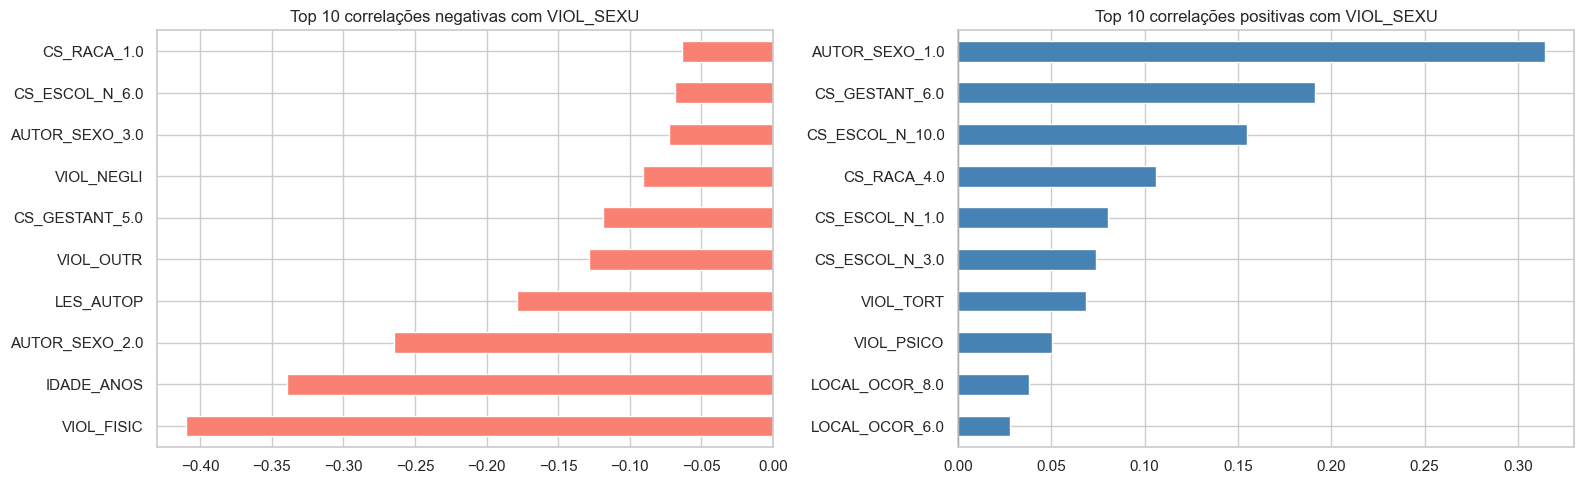

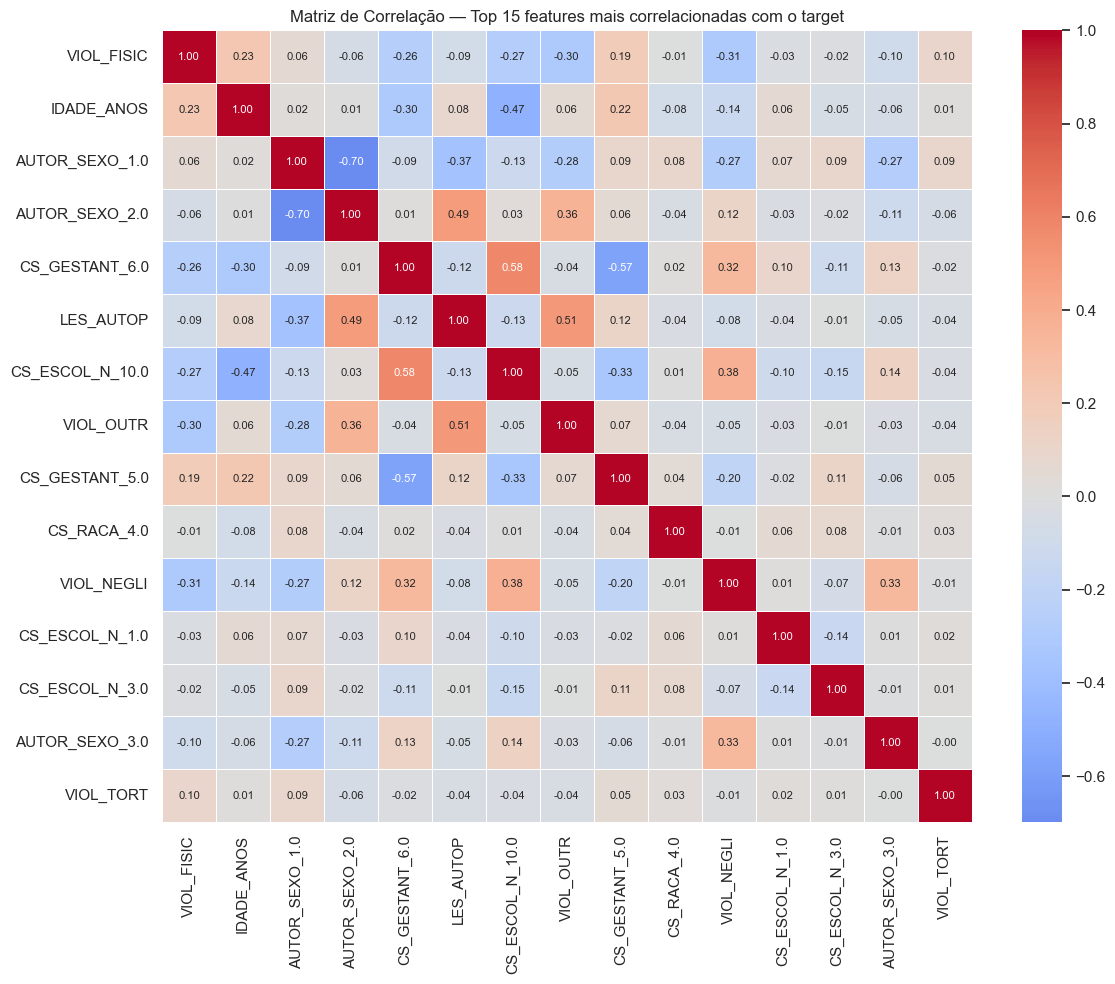

In [22]:
# ── 3.6 Análise de correlação com o target ────────────────────────────────────
corr_with_target = X_df.corrwith(pd.Series(y, name=TARGET)).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Correlações negativas (top 10)
corr_with_target.head(10).plot(kind='barh', ax=axes[0], color='salmon')
axes[0].set_title("Top 10 correlações negativas com VIOL_SEXU")
axes[0].axvline(0, color='black', linewidth=0.8)

# Correlações positivas (top 10)
corr_with_target.tail(10).plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title("Top 10 correlações positivas com VIOL_SEXU")
axes[1].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

# Heatmap das top 15 features mais correlacionadas
top_feats = corr_with_target.abs().nlargest(15).index.tolist()
corr_matrix = X_df[top_feats].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={"size": 8})
plt.title("Matriz de Correlação — Top 15 features mais correlacionadas com o target")
plt.tight_layout()
plt.show()


---
## 4️⃣ Modelagem
---
> Separação treino/teste e criação de três modelos de classificação:
> **Regressão Logística**, **Random Forest** e **XGBoost**.


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Divisão 80/20 estratificada (mantém proporção do target)
X_train, X_test, y_train, y_test = train_test_split(
    X_df.values, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Treino : {X_train.shape[0]:,} amostras  ({y_train.mean()*100:.1f} % positivos)")
print(f"Teste  : {X_test.shape[0]:,} amostras  ({y_test.mean()*100:.1f} % positivos)")

# Normalização para a Regressão Logística
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


Treino : 51,812 amostras  (22.9 % positivos)
Teste  : 12,954 amostras  (22.9 % positivos)


In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Peso para compensar desbalanceamento de classes
neg, pos = np.bincount(y_train.astype(int))
scale_pos = neg / pos

modelos = {
    'Logistic Regression': LogisticRegression(
        max_iter=500, class_weight='balanced', random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=8, class_weight='balanced',
        random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        scale_pos_weight=scale_pos, eval_metric='logloss',
        random_state=42, n_jobs=-1, verbosity=0
    ),
}

print("Modelos configurados:")
for nome in modelos:
    print(f"  ✅ {nome}")


Modelos configurados:
  ✅ Logistic Regression
  ✅ Random Forest
  ✅ XGBoost


---
## 5️⃣ Treinamento e Avaliação dos Modelos
---
> Treinamos cada modelo e avaliamos com métricas de classificação.
> Como o dataset é desbalanceado e o custo de um falso-negativo (não detectar
> violência sexual) é alto, priorizamos **Recall** e **F1-score** além da Acurácia.


In [27]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, classification_report,
                              ConfusionMatrixDisplay)

resultados = {}

for nome, modelo in modelos.items():
    t0 = time.time()
    # Regressão Logística usa dados normalizados
    Xtr = X_train_sc if nome == 'Logistic Regression' else X_train
    Xte = X_test_sc  if nome == 'Logistic Regression' else X_test

    modelo.fit(Xtr, y_train)
    y_pred  = modelo.predict(Xte)
    y_proba = modelo.predict_proba(Xte)[:, 1]

    resultados[nome] = {
        'modelo':     modelo,
        'y_pred':     y_pred,
        'y_proba':    y_proba,
        'accuracy':   accuracy_score (y_test, y_pred),
        'precision':  precision_score(y_test, y_pred, zero_division=0),
        'recall':     recall_score   (y_test, y_pred, zero_division=0),
        'f1':         f1_score       (y_test, y_pred, zero_division=0),
        'roc_auc':    roc_auc_score  (y_test, y_proba),
        'tempo_s':    time.time() - t0,
    }
    print(f"✅ {nome} treinado em {resultados[nome]['tempo_s']:.1f}s")


✅ Logistic Regression treinado em 0.1s
✅ Random Forest treinado em 1.4s
✅ XGBoost treinado em 0.6s


In [28]:
# ── Tabela comparativa de métricas ────────────────────────────────────────────
metricas = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
df_res = pd.DataFrame(
    {nome: {m: resultados[nome][m] for m in metricas} for nome in resultados}
).T.round(4)

df_res.columns = ['Acurácia', 'Precisão', 'Recall', 'F1-Score', 'ROC-AUC']
print("=== Comparativo de Métricas ===")
display(df_res.style.highlight_max(color='lightgreen', axis=0)
               .highlight_min(color='#ffcccc', axis=0))


=== Comparativo de Métricas ===


,Acurácia,Precisão,Recall,F1-Score,ROC-AUC
Logistic Regression,0.860200,0.647500,0.852400,0.736000,0.925600
Random Forest,0.898600,0.745200,0.845700,0.792300,0.949300
XGBoost,0.910100,0.772000,0.861200,0.814200,0.958000


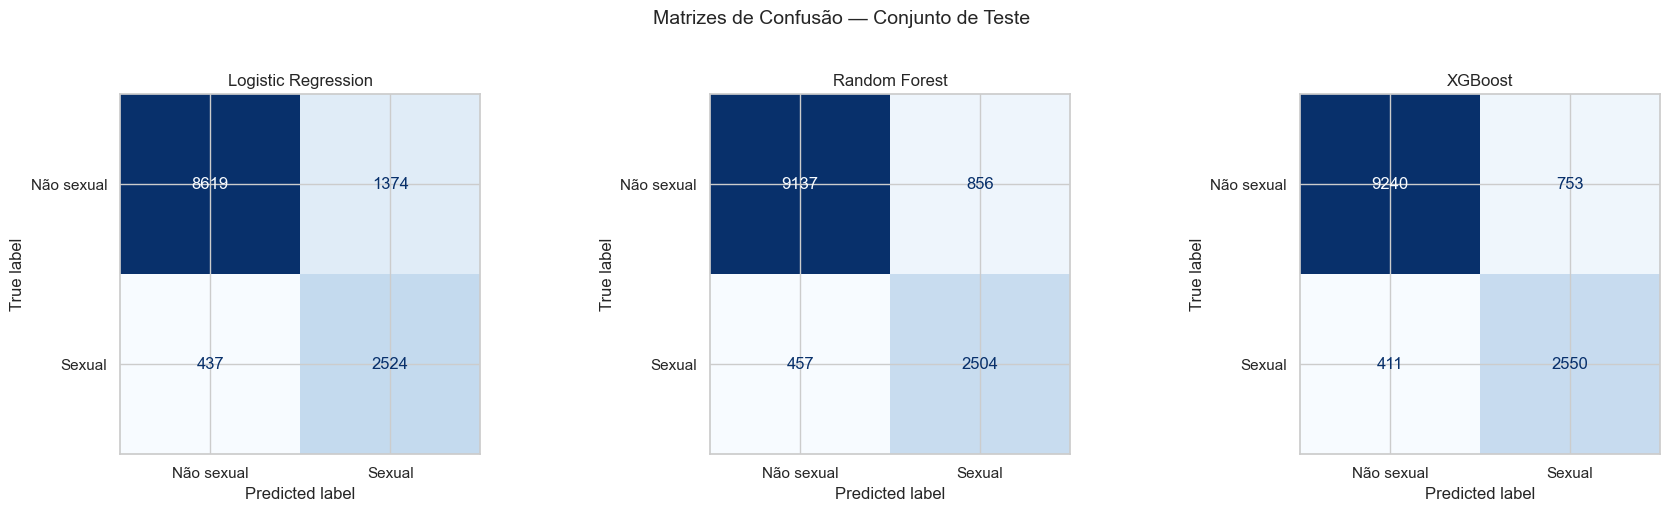

In [29]:
# ── Matrizes de confusão ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (nome, res) in zip(axes, resultados.items()):
    disp = ConfusionMatrixDisplay.from_predictions(
        y_test, res['y_pred'],
        display_labels=['Não sexual', 'Sexual'],
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(nome, fontsize=12)

plt.suptitle("Matrizes de Confusão — Conjunto de Teste", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


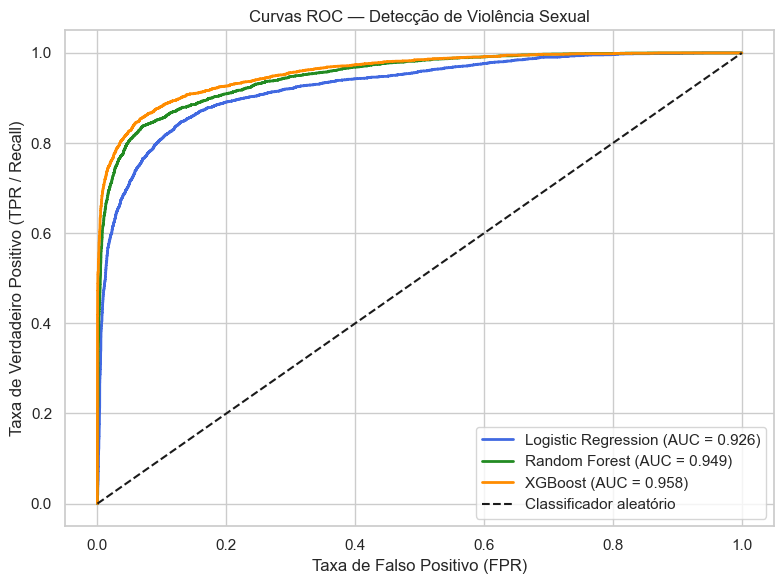

In [30]:
from sklearn.metrics import roc_curve, auc

# ── Curvas ROC ────────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 6))
cores = {'Logistic Regression': 'royalblue',
         'Random Forest': 'forestgreen',
         'XGBoost': 'darkorange'}

for nome, res in resultados.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{nome} (AUC = {roc_auc:.3f})",
             color=cores[nome], lw=2)

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Classificador aleatório')
plt.xlabel("Taxa de Falso Positivo (FPR)")
plt.ylabel("Taxa de Verdadeiro Positivo (TPR / Recall)")
plt.title("Curvas ROC — Detecção de Violência Sexual")
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


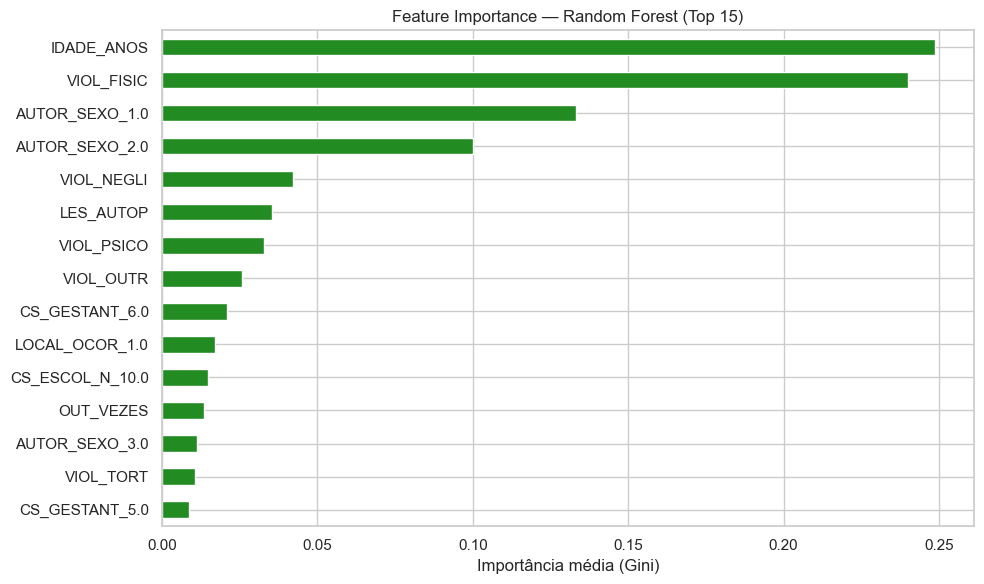

Top 15 features mais importantes:
IDADE_ANOS         0.248836
VIOL_FISIC         0.240015
AUTOR_SEXO_1.0     0.133312
AUTOR_SEXO_2.0     0.099906
VIOL_NEGLI         0.042174
LES_AUTOP          0.035521
VIOL_PSICO         0.032647
VIOL_OUTR          0.025764
CS_GESTANT_6.0     0.020743
LOCAL_OCOR_1.0     0.017055
CS_ESCOL_N_10.0    0.014753
OUT_VEZES          0.013506
AUTOR_SEXO_3.0     0.011188
VIOL_TORT          0.010486
CS_GESTANT_5.0     0.008674


In [31]:
# ── Feature Importance — Random Forest ───────────────────────────────────────
rf_model      = resultados['Random Forest']['modelo']
feature_names = X_df.columns.tolist()
importances   = pd.Series(rf_model.feature_importances_, index=feature_names)
top15         = importances.nlargest(15)

plt.figure(figsize=(10, 6))
top15.sort_values().plot(kind='barh', color='forestgreen')
plt.title("Feature Importance — Random Forest (Top 15)")
plt.xlabel("Importância média (Gini)")
plt.tight_layout()
plt.show()

print("Top 15 features mais importantes:")
print(top15.sort_values(ascending=False).to_string())


=== SHAP Summary Plot — XGBoost ===


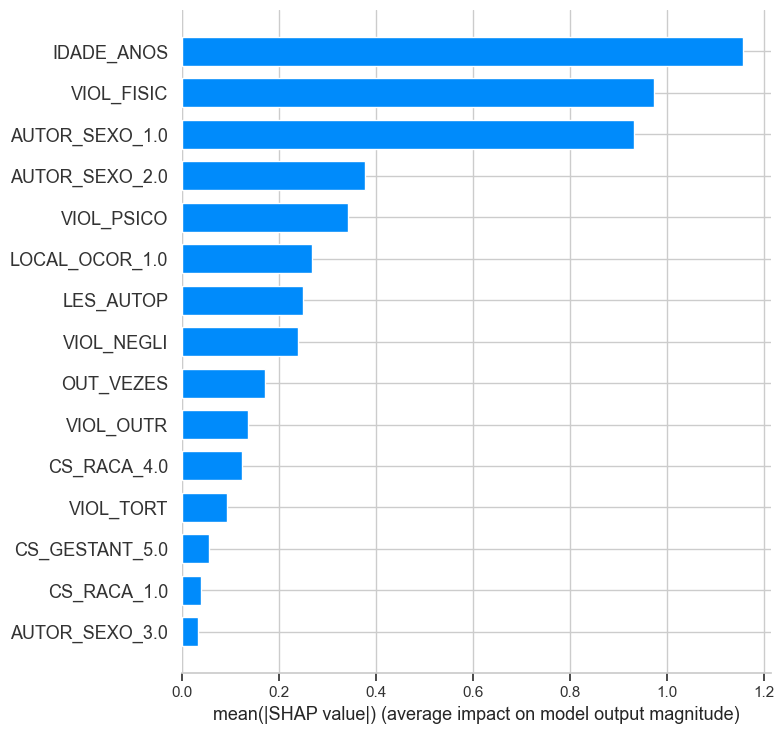


=== SHAP Beeswarm Plot — XGBoost ===


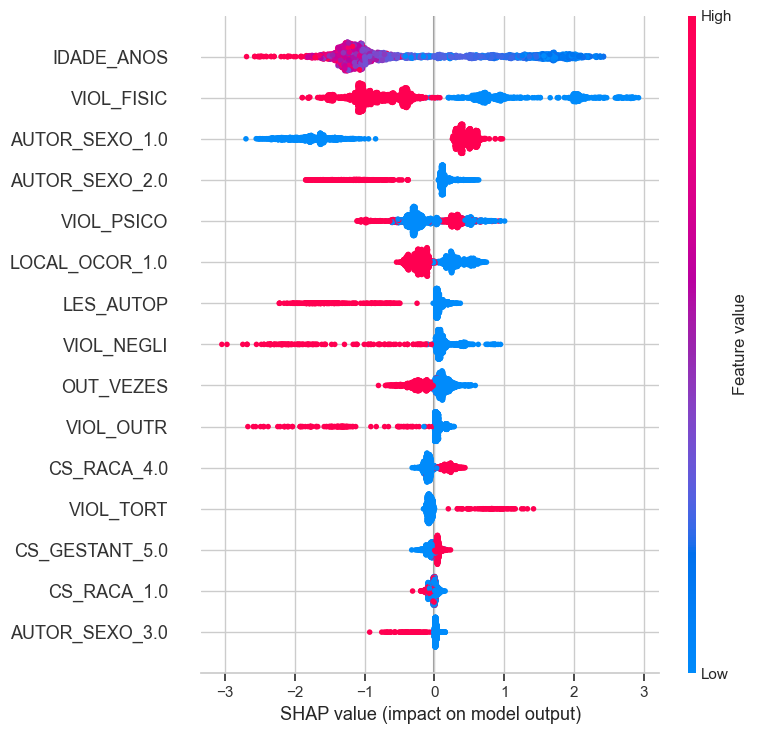

In [32]:
import shap
import numpy as np
 
# ── SHAP — Explicabilidade do XGBoost ─────────────────────────────────────────
xgb_model = resultados['XGBoost']['modelo']
explainer  = shap.TreeExplainer(xgb_model)

# Cria gerador explícito
rng = np.random.default_rng(seed=42)

# Amostra de até 2000 registros para agilizar o cálculo
idx_sample = rng.choice(len(X_test), size=min(2000, len(X_test)), replace=False)
X_sample   = X_test[idx_sample]

shap_values = explainer.shap_values(X_sample)

print("=== SHAP Summary Plot — XGBoost ===")
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_names,
    max_display=15,
    show=True,
    plot_type="bar",
    rng=rng   # passa o gerador explícito
)

print("\n=== SHAP Beeswarm Plot — XGBoost ===")
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_names,
    max_display=15,
    show=True,
    rng=rng   # idem aqui
)


In [ ]:
# ── Relatório de classificação detalhado (melhor modelo por F1) ───────────────
melhor = max(resultados, key=lambda n: resultados[n]['f1'])
print(f"🏆 Melhor modelo por F1-Score: {melhor}\n")
print(classification_report(y_test, resultados[melhor]['y_pred'],
                             target_names=['Não sexual', 'Sexual']))


---
## 6️⃣ Interpretação Crítica dos Resultados
---

### Métricas escolhidas e justificativa
Num sistema de triagem médica, **errar para o lado da segurança** é preferível.
Um **falso-negativo** (não identificar uma vítima de violência sexual) tem custo
muito mais alto do que um falso-positivo (acionar protocolos desnecessariamente).
Por isso priorizamos **Recall** e **F1-score** em detrimento da acurácia pura.
O **ROC-AUC** complementa a análise avaliando o modelo em todos os limiares de
decisão possíveis.

### O que os modelos aprenderam
As features com maior impacto identificadas pelo SHAP/Feature Importance revelam
que **tipo de violência co-ocorrente** (física, psicológica) e **características
do agressor** (sexo, uso de álcool) são os principais sinais preditivos, em
consonância com a literatura sobre violência doméstica.

### Pode ser usado na prática?
O modelo **pode apoiar** a triagem clínica, funcionando como:
- Um **alerta automático** nos sistemas de prontuário eletrônico quando os campos
  de notificação sugerem alta probabilidade de violência sexual;
- Uma **ferramenta de priorização** para que enfermeiras/agentes de saúde identifiquem
  casos que precisam de encaminhamento urgente (protocolo de violência sexual do
  Ministério da Saúde).

**Limitações e cuidados éticos:**
- O modelo foi treinado em notificações já **registradas**; casos não notificados
  (subnotificação) criam viés;
- Dados com muitos campos ignorados (9) reduzem a qualidade das previsões;
- O **profissional de saúde deve sempre ter a palavra final** no diagnóstico;
- Qualquer uso do modelo deve estar em conformidade com a **LGPD (Lei nº 13.709/2018)**.

### Próximos passos sugeridos
1. Coleta de dados mais completa (reduzir `9 = ignorado`);
2. Validação com dados de outros anos e outras UFs;
3. Explorar modelos interpretáveis (e.g., EBM — Explainable Boosting Machine);
4. Integração com sistemas de prontuário eletrônico (RES/RNDS).


---
## 7️⃣ Persistência do Modelo — Embarcação na API Flask
---
> Salva o melhor modelo (XGBoost), o imputador de valores ausentes, o scaler e a lista de features.  
> Todos os artefatos ficam na pasta `model/` e podem ser carregados diretamente na API Flask com `joblib.load()`.


In [ ]:
# ── 7️⃣ Salvar modelo para embarcação na API Flask ──────────────────────────────
import joblib
import os

MODEL_DIR = "model"
os.makedirs(MODEL_DIR, exist_ok=True)

# Salva o melhor modelo (XGBoost)
joblib.dump(resultados["XGBoost"]["modelo"], os.path.join(MODEL_DIR, "xgb_viol_sexu.joblib"))
print("✅ Modelo XGBoost salvo em model/xgb_viol_sexu.joblib")

# Salva o imputador de valores ausentes (mediana)
joblib.dump(imputer, os.path.join(MODEL_DIR, "imputer.joblib"))
print("✅ Imputador salvo em model/imputer.joblib")

# Salva o scaler (StandardScaler — usado pela Logistic Regression, útil como referência)
joblib.dump(scaler, os.path.join(MODEL_DIR, "scaler.joblib"))
print("✅ Scaler salvo em model/scaler.joblib")

# Salva a lista de colunas de entrada (ordem exata esperada pelo modelo)
feature_columns = X_df.columns.tolist()
joblib.dump(feature_columns, os.path.join(MODEL_DIR, "feature_columns.joblib"))
print(f"✅ {len(feature_columns)} colunas salvas em model/feature_columns.joblib")
print(f"
Colunas: {feature_columns}")


---
## 8️⃣ Geração do Relatório PDF — Tech Challenge - Fase 1
---
> Executa o script `gerar_relatorio.py` para gerar o relatório PDF completo em `documentos/TechChallenge_Fase1_Relatorio_Completo.pdf`.  
> O relatório inclui título correto, todas as seções técnicas e interpretações dos gráficos.  
> **Pré-requisito:** `pip install weasyprint`


In [ ]:
# ── 8️⃣ Gerar relatório PDF ───────────────────────────────────────────────────
# Requer: pip install weasyprint
import subprocess
import sys

result = subprocess.run(
    [sys.executable, "gerar_relatorio.py"],
    capture_output=True, text=True
)
print(result.stdout)
if result.returncode != 0:
    print("ERRO:", result.stderr)
